In [1]:
import numpy as np # 넘파이 사용
import matplotlib.pyplot as plt # 맷플롯립사용

## 1. 회귀와 분류
- 주어진 입력값을 토대로 얻고자 하는 출력값이 연속적인 값일 때에는 회귀, 이산적인 값일 때에는 분류로 생각할 수 있다.
- 회귀의 경우, 주어진 자료에 오차가 가장 적도록 선형함수를 적합시키고, 이 선형함수를 통해 주어진 입력값을 예측값으로 변환한다.
- 분류의 경우, 주어진 입력값을 이산적인 레이블로 나눈다. 출력값이 연속적일 경우 이를 이산적인 레이블에 맞춰 분류하기 곤란하다.
- 로지스틱 회귀의 경우, 알고리즘은 회귀의 형태를 따르나 실제 작업은 분류에 사용된다.

## 2. 이진 분류(Binary Classification)
### 2.1 이진 분류의 특징
- 분류 작업에 주어진 레이블이 둘일 경우, 이진 분류라고 부른다.
- 이진 분류 작업을 위해서는 주어진 입력값을 두 극단값 중 하나로 분류해야 한다.
- 즉, 이진 분류에 사용하기 적합한 모델의 특징은 아래와 같다
  - 정의역이 넓어서 가능한 많은 입력값을 받을 수 있어야 한다.
  - 주어진 입력의 차이를 확대 및 과장하여 극단적인 값으로 보내야 한다.

### 2.2 시그모이드 함수(Sigmoid function)
$$ \sigma(Wx+b) = \frac{1}{1+\exp^{-1(Wa+b)}} $$
- 시그모이드 함수는 아래와 같은 특징을 가진다.
  - 실수 전체를 정의역으로 가지므로 모든 범위의 입력값을 받을 수 있다.
  - 중앙부에서는 경사가 충분히 커서 주어진 입력값의 차이를 확대할 수 있다.
  - 출력값이 0과 1 사이의 값을 가져 확률값( $p(y=1|x)$ )으로 간주될 수 있다.
  - 미분이 쉬워 경사하강법에 적합하다.

In [2]:
def sigmoid(x): # 시그모이드 함수 정의
    return 1/(1+np.exp(-x))

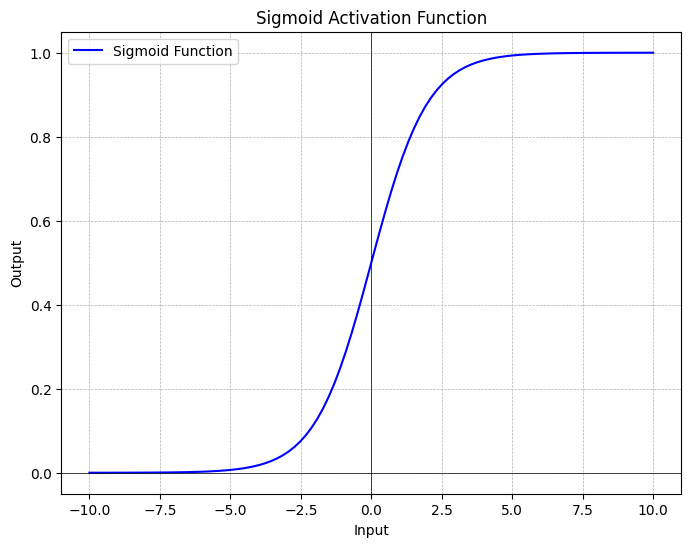

In [3]:
fig, ax = plt.subplots(figsize=(8, 6)) # 그래프 크기 설정
x = np.linspace(-10, 10, 100) # -10에서 10까지 100개의 점 생성
y = sigmoid(x) # 시그모이드 함수 적용
ax.plot(x, y, label='Sigmoid Function', color='blue') # 그래프 그리기
ax.axhline(0, color='black',linewidth=0.5, ls='-') # x축 추가
ax.axvline(0, color='black',linewidth=0.5, ls='-') # y축 추가
ax.grid(True, linestyle='--', linewidth=0.5) # 격자 추가
ax.set_title('Sigmoid Activation Function') # 그래프 제목 설정
ax.set_xlabel('Input') # x축 라벨 설정
ax.set_ylabel('Output') # y축 라벨 설정
ax.legend() # 범례 추가
plt.show()

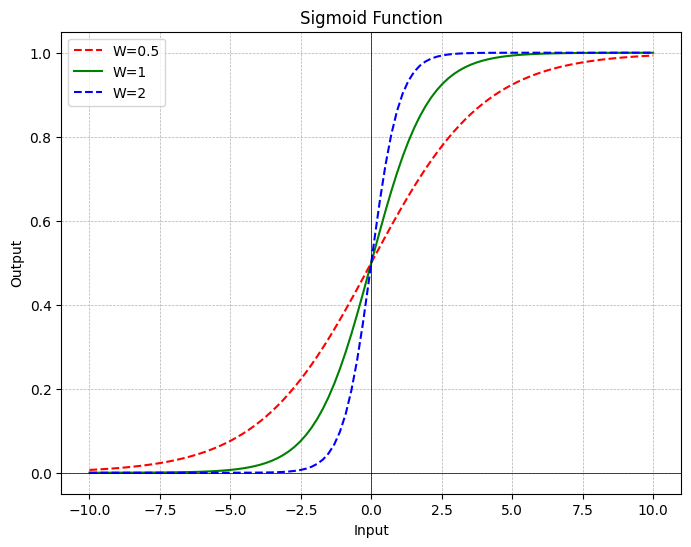

In [4]:
x = np.linspace(-10, 10, 100) # -10에서 10까지 100개의 점 생성
y1 = sigmoid(0.5*x)
y2 = sigmoid(x)
y3 = sigmoid(2*x)

fig, ax = plt.subplots(figsize=(8, 6)) # 그래프 크기 설정
ax.plot(x, y1, label='W=0.5', color='r', linestyle='--') # W의 값이 0.5일때
ax.plot(x, y2, label='W=1', color='g') # W의 값이 1일때
ax.plot(x, y3, label='W=2', color='b', linestyle='--') # W의 값이 2일때
ax.axhline(0, color='black',linewidth=0.5, ls='-') # x축 추가
ax.axvline(0, color='black',linewidth=0.5, ls='-') # y축 추가
ax.grid(True, linestyle='--', linewidth=0.5) # 격자 추가
ax.set_title('Sigmoid Function')
ax.set_xlabel('Input') # x축 라벨 설정
ax.set_ylabel('Output') # y축 라벨 설정
ax.legend() # 범례 추가
plt.show()

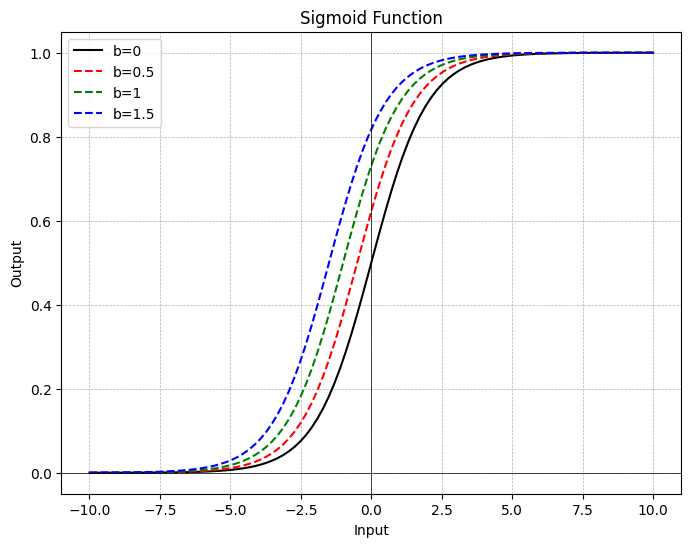

In [5]:
x = np.linspace(-10, 10, 100) # -10에서 10까지 100개의 점 생성
y0 = sigmoid(x)
y1 = sigmoid(x+0.5)
y2 = sigmoid(x+1)
y3 = sigmoid(x+1.5)

fig, ax = plt.subplots(figsize=(8, 6)) # 그래프 크기 설정
ax.plot(x, y0, label="b=0", color='k', linestyle='-') # x
ax.plot(x, y1, label="b=0.5", color='r', linestyle='--') # x + 0.5
ax.plot(x, y2, label="b=1", color='g', linestyle='--') # x + 1
ax.plot(x, y3, label="b=1.5", color='b', linestyle='--') # x + 1.5
ax.axhline(0, color='black',linewidth=0.5, ls='-') # x축 추가
ax.axvline(0, color='black',linewidth=0.5, ls='-') # y축 추가
ax.grid(True, linestyle='--', linewidth=0.5) # 격자 추가
ax.set_title('Sigmoid Function')
ax.set_xlabel('Input') # x축 라벨 설정
ax.set_ylabel('Output') # y축 라벨 설정
ax.legend() # 범례 추가
plt.show()

## 3. 비용 함수(Cost Function)
- 비용함수는 아래와 같은 특징을 가져야 한다.
  - 목표값과 출력값이 같을 경우 가장 작은 값을 출력한다.
  - 목표값과 출력값이 다를수록 출력값이 커져야 한다.
  - 기울기 소실(Gradient Vanishing)이 일어나지 않아야 한다.
- `MSE` 함수를 시그모이드 모델에 사용할 경우 아래와 같은 문제가 발생한다.
  - 시그모이드 함수는 양 극단에서 기울기가 작아지므로, 목표값과의 차이 제곱인 `MSE` 역시 양 극단에서 기울기가 작아진다.
  - 따라서 경사하강법에 따라 그래프를 타기 어려우며, 학습에 어려움이 있을 수 있다.
- `BCE` 함수를 시그모이드 모델에 사용할 경우 이런 문제가 해결된다.
  - 이는 서로 대칭인 두 로그함수를 목표값으로 가중평균한 것으로, 양 극단에서의 시그모이드 함수의 기울기 소실을 극복할 수 있다.
  - 단, 입력값이 0이나 1에 가까워질수록 $\log(0)$으로 발산하기에 선형함수에 대한 손실함수로는 사용할 수 없다.

$$\text{BCE} = -[y\log H(x) + (1-y)\log G(x)]$$
$$\text{where } G(x) = 1 - H(x)$$

/tmp/ipykernel_76462/4093903094.py:14: RuntimeWarning: invalid value encountered in log
  bce_linear = -(y_target * np.log(linear_preds + 1e-10) + (1 - y_target) * np.log(1 - linear_preds + 1e-10))


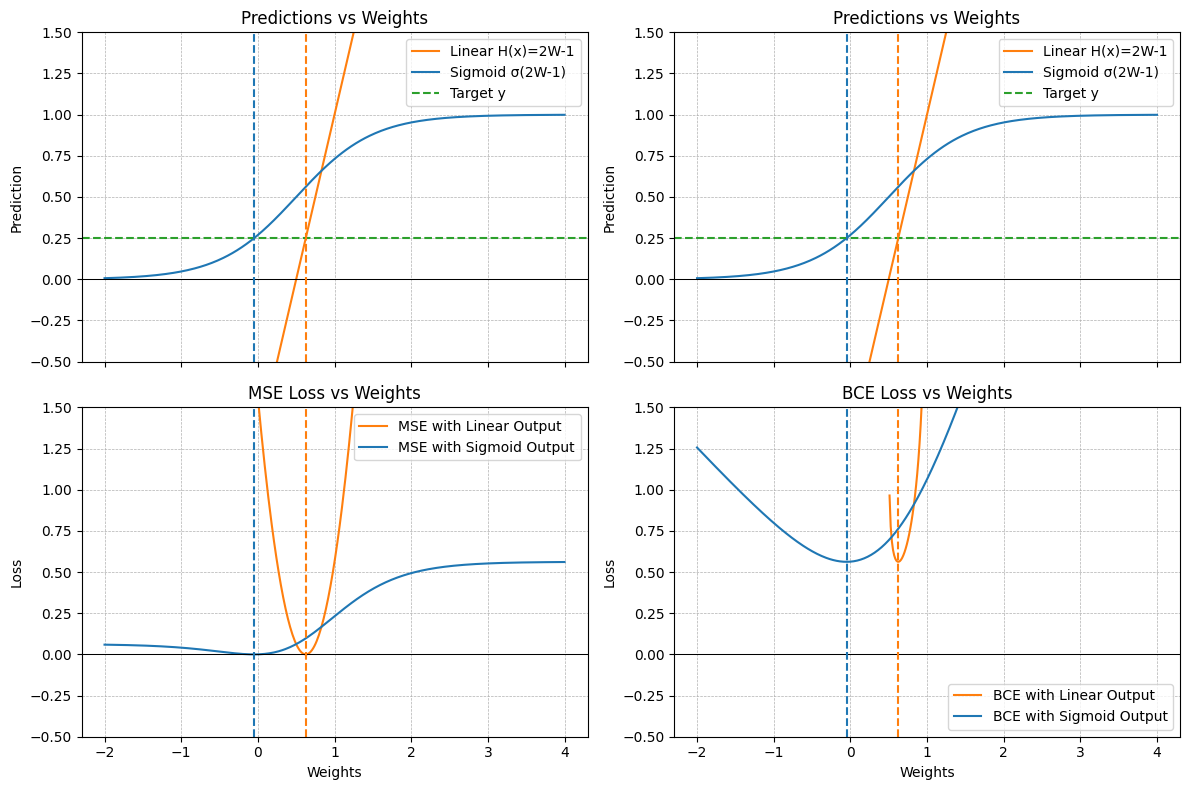

In [6]:
x_val = 2.0
b_val = -1.0
y_target = 0.25
weights = np.linspace(-2.0, 4.0, 400)

logits = weights * x_val + b_val
linear_preds = logits
sigmoid_preds = sigmoid(logits)
linear_target_weight = (y_target - b_val) / x_val
sigmoid_target_weight = (np.log(y_target/(1 - y_target)) - b_val) / x_val

mse_linear = (y_target - linear_preds) ** 2
mse_sigmoid = (y_target - sigmoid_preds) ** 2
bce_linear = -(y_target * np.log(linear_preds + 1e-10) + (1 - y_target) * np.log(1 - linear_preds + 1e-10))
bce_sigmoid = -(y_target * np.log(sigmoid_preds + 1e-10) + (1 - y_target) * np.log(1 - sigmoid_preds + 1e-10))

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

axes[0,0].plot(weights, linear_preds, label="Linear H(x)=2W-1", color='tab:orange')
axes[0,0].plot(weights, sigmoid_preds, label="Sigmoid σ(2W-1)", color='tab:blue')
axes[0,0].axhline(y_target, color='tab:green', linestyle='--', label='Target y')
axes[0,0].axhline(0, color='black', linewidth=0.75, ls='-')
axes[0,0].axvline(linear_target_weight, color='tab:orange', linestyle='--')
axes[0,0].axvline(sigmoid_target_weight, color='tab:blue', linestyle='--')
axes[0,0].set_title('Predictions vs Weights')
axes[0,0].set_ylabel('Prediction')
axes[0,0].set_ylim(-0.5, 1.5)
axes[0,0].legend()
axes[0,0].grid(True, linestyle='--', linewidth=0.5)

axes[1,0].plot(weights, mse_linear, label='MSE with Linear Output', color='tab:orange')
axes[1,0].plot(weights, mse_sigmoid, label='MSE with Sigmoid Output', color='tab:blue')
axes[1,0].axhline(0, color='black', linewidth=0.75, ls='-')
axes[1,0].axvline(linear_target_weight, color='tab:orange', linestyle='--')
axes[1,0].axvline(sigmoid_target_weight, color='tab:blue', linestyle='--')
axes[1,0].set_title('MSE Loss vs Weights')
axes[1,0].set_ylabel('Loss')
axes[1,0].set_xlabel('Weights')
axes[1,0].legend()
axes[1,0].set_ylim(-0.5, 1.5)
axes[1,0].grid(True, linestyle='--', linewidth=0.5)

axes[0,1].plot(weights, linear_preds, label="Linear H(x)=2W-1", color='tab:orange')
axes[0,1].plot(weights, sigmoid_preds, label="Sigmoid σ(2W-1)", color='tab:blue')
axes[0,1].axhline(y_target, color='tab:green', linestyle='--', label='Target y')
axes[0,1].axhline(0, color='black', linewidth=0.75, ls='-')
axes[0,1].axvline(linear_target_weight, color='tab:orange', linestyle='--')
axes[0,1].axvline(sigmoid_target_weight, color='tab:blue', linestyle='--')
axes[0,1].set_title('Predictions vs Weights')
axes[0,1].set_ylabel('Prediction')
axes[0,1].set_ylim(-0.5, 1.5)
axes[0,1].legend()
axes[0,1].grid(True, linestyle='--', linewidth=0.5)

axes[1,1].plot(weights, bce_linear, label='BCE with Linear Output', color='tab:orange')
axes[1,1].plot(weights, bce_sigmoid, label='BCE with Sigmoid Output', color='tab:blue')
axes[1,1].axhline(0, color='black', linewidth=0.75, ls='-')
axes[1,1].axvline(linear_target_weight, color='tab:orange', linestyle='--')
axes[1,1].axvline(sigmoid_target_weight, color='tab:blue', linestyle='--')
axes[1,1].set_title('BCE Loss vs Weights')
axes[1,1].set_ylabel('Loss')
axes[1,1].set_xlabel('Weights')
axes[1,1].legend()
axes[1,1].set_ylim(-0.5, 1.5)
axes[1,1].grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

## 4. 파이토치로 로지스틱 회귀 구현하기

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [8]:
torch.manual_seed(1)

In [9]:
x_data = [[1, 2], [2, 3], [3, 1], [4, 3], [5, 3], [6, 2]]
y_data = [[0], [0], [0], [1], [1], [1]]
x_train = torch.FloatTensor(x_data)
y_train = torch.FloatTensor(y_data)

In [10]:
print(x_train.shape)
print(y_train.shape)

torch.Size([6, 2])
torch.Size([6, 1])


In [11]:
W = torch.zeros((2, 1), requires_grad=True) # 크기는 2 x 1
b = torch.zeros(1, requires_grad=True)

In [12]:
hypothesis = 1 / (1 + torch.exp(-(x_train.matmul(W) + b)))

In [13]:
print(hypothesis) # 예측값인 H(x) 출력

tensor([[0.5000],
        [0.5000],
        [0.5000],
        [0.5000],
        [0.5000],
        [0.5000]], grad_fn=<MulBackward0>)


In [14]:
hypothesis = torch.sigmoid(x_train.matmul(W) + b)

In [15]:
print(hypothesis)

tensor([[0.5000],
        [0.5000],
        [0.5000],
        [0.5000],
        [0.5000],
        [0.5000]], grad_fn=<SigmoidBackward0>)


In [16]:
print(hypothesis)
print(y_train)

tensor([[0.5000],
        [0.5000],
        [0.5000],
        [0.5000],
        [0.5000],
        [0.5000]], grad_fn=<SigmoidBackward0>)
tensor([[0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.]])


In [17]:
losses = -(y_train * torch.log(hypothesis) +
           (1 - y_train) * torch.log(1 - hypothesis)) # BCE 계산
print(losses)

tensor([[0.6931],
        [0.6931],
        [0.6931],
        [0.6931],
        [0.6931],
        [0.6931]], grad_fn=<NegBackward0>)


In [18]:
cost = losses.mean()
print(cost)

tensor(0.6931, grad_fn=<MeanBackward0>)


In [19]:
F.binary_cross_entropy(hypothesis, y_train) # PyTorch 내장 함수로 BCE 계산

tensor(0.6931, grad_fn=<BinaryCrossEntropyBackward0>)

In [20]:
x_data = [[1, 2], [2, 3], [3, 1], [4, 3], [5, 3], [6, 2]]
y_data = [[0], [0], [0], [1], [1], [1]]
x_train = torch.FloatTensor(x_data)
y_train = torch.FloatTensor(y_data)

In [21]:
# 모델 초기화
W = torch.zeros((2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)
# optimizer 설정
optimizer = optim.SGD([W, b], lr=1)

nb_epochs = 1000
for epoch in range(nb_epochs + 1):

    # Cost 계산
    hypothesis = torch.sigmoid(x_train.matmul(W) + b)
    cost = -(y_train * torch.log(hypothesis) +
             (1 - y_train) * torch.log(1 - hypothesis)).mean()

    # cost로 H(x) 개선
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    # 100번마다 로그 출력
    if epoch % 100 == 0:
        print('Epoch {:4d}/{} Cost: {:.6f}'.format(
            epoch, nb_epochs, cost.item()
        ))

Epoch    0/1000 Cost: 0.693147
Epoch  100/1000 Cost: 0.134722
Epoch  200/1000 Cost: 0.080643
Epoch  300/1000 Cost: 0.057900
Epoch  400/1000 Cost: 0.045300
Epoch  500/1000 Cost: 0.037261
Epoch  600/1000 Cost: 0.031673
Epoch  700/1000 Cost: 0.027556
Epoch  800/1000 Cost: 0.024394
Epoch  900/1000 Cost: 0.021888
Epoch 1000/1000 Cost: 0.019852


In [22]:
hypothesis = torch.sigmoid(x_train.matmul(W) + b)
print(hypothesis)

tensor([[2.7648e-04],
        [3.1608e-02],
        [3.8977e-02],
        [9.5622e-01],
        [9.9823e-01],
        [9.9969e-01]], grad_fn=<SigmoidBackward0>)


In [23]:
prediction = hypothesis >= torch.FloatTensor([0.5])
print(prediction)

tensor([[False],
        [False],
        [False],
        [ True],
        [ True],
        [ True]])


In [24]:
print(W)
print(b)

tensor([[3.2530],
        [1.5179]], requires_grad=True)
tensor([-14.4819], requires_grad=True)
